# Final Assignment RO47002 - Machine Learning for Robotics 2024/2025

Before you start, fill in the cell below your lab group's number and the names of both lab partners.
It is also suggested that you carefully read through all provided content before you start adding things.

*Note*: as always, basic plagiarism and ethical guidelines apply:
* By submitting this notebook, **you both claim that the solution is yours and yours only.**
* You are not allowed to share your work with others.
* Even after the deadline has passed, do *not* share or upload your solution anywhere (e.g. do not put it on github).

In [3]:
GROUP_NUMBER = "23"
STUDENT_NAME1 = "Daniel Rugge"
STUDENT_NUMBER1 = "4713729"
STUDENT_NAME2 = "Daan Bouwmeester"
STUDENT_NUMBER2 = "5146143"

In [4]:
# Note: this block is a check that you have filled in the above information.
# It will throw an AssertionError until all fields are filled
assert(GROUP_NUMBER != "")
assert(STUDENT_NAME1 != "")
assert(STUDENT_NUMBER1 != "")
assert(STUDENT_NAME2 != "")
assert(STUDENT_NUMBER2 != "")

---

## Introduction
We are in the year 2123. With the rapid development of autonomous systems, tech companies are exploring more advanced robotic capabilities to assist in various real-world scenarios. Your employer is working on an innovative feature for their robots, aimed at enabling their robots to navigate through complex outdoor environments and efficiently retrieve objects for their owners. The current focus of development is on enabling the robot to identify and reach a specific object, such as a red box, while navigating through an environment with physical boundaries and obstacles. The goal is to teach the robot to reach the red box within the least number of steps, optimizing both its efficiency and decision-making.

For the upcoming demo to their stakeholders, the robot will be placed in an outdoor environment that simulates two rooms, connected by a gap in the wall. The red box will be located in one of the rooms, and **the robot must navigate from its starting point through the gap to reach the box without touching the wall**. To prepare for the demo, your employer has booked three timeslots with the robot throughout the week. These timeslots ('Time 0', 'Time 1', and 'Time 2') are at different times of the day.

As you are just starting out as a robot AI engineer, you first get the familiarization assignment to train a model solely for opperating at 'Time 1' before moving on to designing a more general AI.

## Robot AI

In this task, the robot's actions need to be determined based on only the robot's last observation (i.e. sensor measurements). More technically: the goal is to create a function $policy(observation) \rightarrow action$, which the robot can continuously apply in a loop on its sensor measurements to determine its next action. This type of function is often called a *policy*.

In this assignment, the input and output of the policy function `policy` are defined as:
- the input `observation` will be an RGB image (a numpy array) containing a view of the robot's surroundings.
- the output `action` should be an integer out of one of the possible actions (an integer between 0 and 2):

    0. Turn left
    1. Turn right
    2. Move forward

[comment]:<> (More details will be provided later in the section 0. Code to get you started" below.)

Note that the policy function will completely determine the behavior of the robot.
You can think of the robot executing the policy in a never-ending loop (in pseudo-code):
```python
# Pseudo robot main loop with policy f
while True:
    observation = read_sensor_measurement()
    action = policy(observation) # apply the policy
    execute_action(action)
```
In fact, the behavior is already implemented for you in a **simulator**. This means you can test a policy function `policy` by plugging it in the simulator and seeing how your robot behaves!
The simulator also allows us to quantify how well your robot behaved by returning a 'reward' value for each simulation step (a higher reward is better). More details on the rewards will be explained below in Section 0.

## Task description: imitation learning

These type of tasks, where a robot's policy needs to be optimized to achieve a high expected reward for operating in some environment, is often addressed through *reinforcement learning*. However, in this assignment we will *not* use reinforcement learning techniques, but mainly treat the problem as a **supervised classification task**.
The training input (observations) and output (action labels) data will be obtained through demonstrations of humans *manually* controlling the robot. By training your machine learning models on these demonstrations, you will create an AI which "imitates" how a human would control the robot. This type of supervised machine learning is therefore called *imitation learning*.

There are some coding challenges and design choices that you have to solve to use human demonstrations as labeled data to create your machine learning models. As before, you will have to think about feature extraction, hyperparemeter optimization, evaluation metrics, comparing models, etc.

Once you have trained a classification model, you could define a new policy function which uses your trained model, and test this policy in the simulator. Does your most successful model also accumulate the most reward in the simulation? Can you make an AI which successfully operates at recorded and unrecorded times of the day?

## Deliverables
The deadline is **Monday, October 28th, 2024 at 23:59**. Late submission is –1 grade point per day.

* The main deliverable is this Jupyter Notebook, integrating the report (markdown cells) and the code.
* Submission is again in the form of a single ZIP file that *includes your notebook, and all files required to run the notebook and reproduce the results*. This includes all used data/demonstrations (including the ones that were provided), any loadable parameter files, any auxiliary scripts, etc.
* Name the ZIP file "**GroupNumber_final_assignment.zip**", e.g., if you are in group 456, the name would be "456_final_assignment.zip".
* Unlike previous lab assignments, there are no autograded cells or asserts, but we will grade the notebook manually. Therefore, you are free to add cells as you see fit, as long as the required sections are still present in the notebook.
* Make sure that the notebook runs correctly. That is, clear all outputs, restart the kernel and run the notebook from top to bottom. 
* The notebook needs to be able to run within 20 minutes on a high-end PC, performing all steps (also including training, the only exception is hyperparameter optimization which can be commented out).
* In contrast to the practica, please submit the notebook *including* the output (i.e., do not clear the outputs before zipping it up). 


## Grading Criteria
Below you will find an outline of the sections that the notebook needs to contain and what we expect for each part. More specific requirements are listed there as well. The indicated number of points, out of a total of 100, should give you a rough indication of how much effort to put into each part.

<div class="alert alert-block alert-warning">
In general, we will not focus as much on the performance of the method you design, but rather the <b>level of understanding and argumentation about your design choices</b>. So, we are not only interested in WHAT you did, but will put a strong emphasis on your reasoning about the WHY. Try to synthesize rather than describing what you did step by step.
</div>

### Quality of the report (20 points)
- Structure & Readability
 - Logical flow
 - Connection between parts
- Academic English
 - Do not use short forms, so not "isn't" / "wouldn't" but "is not" / "would not".
 - Do not use colloquial style, like "a couple of".
 - Spell check and proofread your report.
- Level of detail
 - Strive for elegant, concise text - longer reports do not necessarily yield higher grades.
 - There is no need to re-explain theory. Assume that the target audience of the report has followed the course.
- Figures & Tables
 - Choose figures/plots/tables carefully. Only include those that add to the story of the report. Do not put the burden on the reviewer to figure out which results you are basing your conclusions on, but specifically refer (parts of) the specific table/plot/figure when needed.
 - When comparing two or more signals display them in one plot. Explain the colors / line types. The scale of the plots must be carefully chosen in order to clearly convey the information intended. Label the axes in graphs properly (variables and units).
- Citations
 - If you use images, theory and methods beyond what was covered in the course, etc., always reference sources.


### Your implementations and answers (80 points)

The remainder of this notebook follows the following structure:

0. Code to get you started (0 points, *nothing for you to do here*)
1. Explore & Inspect the Data (5 points)
2. Prepare the Data and Evaluate Features (15 points)
3. Single Time of Day Action Classification  (35 points)
4. Enabling Generalization (20 points)
5. Present your solution (5 points)

Apart from section 0, you will have to implement and answer questions for all of the other 5 sections to earn points. *For each of these 5 sections, we have various questions or implementation tasks that your submission should address. These are listed in the cells at the end of this notebook.*

Note that there is not one best answer to these questions, and the task could be addressed in different ways. We want to know *your* motivation for *your* selected approach.

---

# 0. Code to get you started

Before you start working on this notebook, **you will first need to install the Miniworld environment in your `homl3` conda environment**
```
pip install miniworld
```

**You will also need to install OpenCV in your `homl3` conda environment**
```
pip install opencv-python
```

<div class="alert alert-block alert-info">
If you encounter "zmq message arrived on closed channel" errors when working on this notebook, ensure that you do not have AdBlockers, Firewalls or similar active. If this does not resolve the issue, contact us regarding your particular case.
</div>

Note, you will not have to implement anything in this section, but you are free to play around with what is provided here, or copy parts to new cells in your solutions.

## Global flags

Here we define two global flags that will influence if this notebook will show popup windows when running the simulation:
- `show_policy` defines whether you will see a pop-up window visualizing the policy from a random initial configuration
- `collect_demo` defines whether you will see an interactive window that allows you to collect your own demonstrations

Feel free to change the flags later if you need. For instance, if you want to test if your notebook runs properly and reproduces your results, but you do not want to wait for the popup windows, you can set these flags to False.

In [5]:
# Configure if the simulator should show pop-up windows
# CHANGE IF NEEDED
show_policy = True
collect_demo = True

In [6]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


## Load default modules

In [2]:
import pickle
import numpy as np

import matplotlib.pyplot as plt
 
import cv2 # you are allowed to use functions from cv2
import glob

# import the simulation environment
import wallgap_ro47002
from wallgap_ro47002 import WallGap


In [8]:
# (this cell is included for debugging, it makes it easy to reload wallgap_ro47002.py without restarting the kernel)
import importlib
importlib.reload(wallgap_ro47002)
from wallgap_ro47002 import WallGap

In [3]:
# creating environments for the 4 environments with rendering
envs = []
 
for n in range(4): 
    envs.append(WallGap(time_id=n, max_episode_time_step=1000, rendering=False))

# creating environments for the 4 environments without rendering
envs_norender = []
 
for n in range(4): 
    envs_norender.append(WallGap(time_id=n, max_episode_time_step=1000, rendering=False)) 
    
# N.B.: on some computer you might get a warning "Cannot change thread mode after it is set"
# when you run this cell the first time. It is safe to ignore this warning, the notebook should still work properly.

time_id: 0
time_id: 1
time_id: 2
time_id: 3
time_id: 0
time_id: 1
time_id: 2
time_id: 3


First, we explore the available environments. The code below generates an image from the 3 environments. You do not need to understand how this code works, but it should help you understand the context of what we are doing.

[[5.  0.  0.5]
 [5.  0.  6. ]]


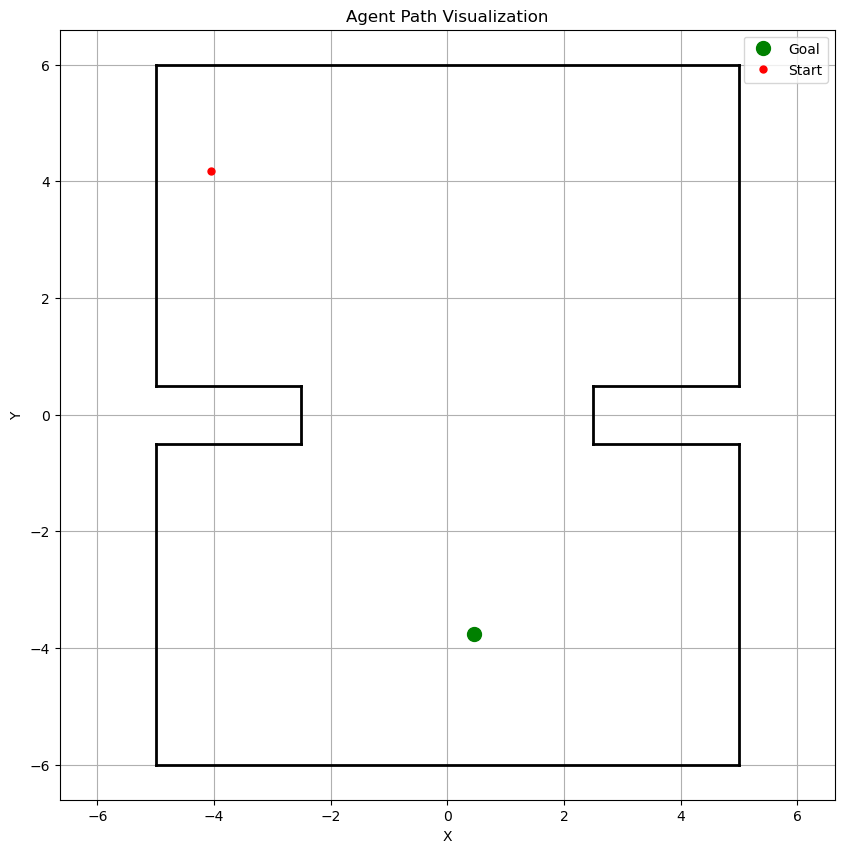

In [18]:
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

def plot_environment(agent_path, wall_endpoints, goal_location):
    plt.figure(figsize=(10, 10))
    
    # Plot walls
    for wall in wall_endpoints:
        p1, p2 = wall
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', linewidth=2)

    # Plot goal
    plt.plot(goal_location[0], goal_location[1], 'go', markersize=10, label='Goal')

    # Plot agent path
    agent_path = np.array(agent_path)
    plt.plot(agent_path[0, 0], agent_path[0, 1], 'ro', markersize=5, label='Start')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Agent Path Visualization')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

env = envs[0]
seed=0
env.reset(seed=seed)
agent = env.agent
goal_location = env.box.pos
goal_location = [goal_location[0], goal_location[2]]

fwd_step = env.params.sample(None, "forward_step")
turn_step = env.params.sample(None, "turn_step")
print(env.wall_segs[0])
wall_endpoints = [[[wall[0,0], wall[0,2]], [wall[1,0], wall[1,2]]] for wall in env.wall_segs]
agent_path = [[agent.pos[0], agent.pos[2]]]

# Plot
plot_environment(agent_path, wall_endpoints, goal_location)

In [11]:
import ipywidgets
import pyglet
%matplotlib inline
# Show screenshot of a sampled environment
def plot_time_example(time_id):
    env = envs_norender[time_id]
    env.reset(seed=1)
    plt.imshow(env.render())
    env.render()
    plt.title(f'Time {time_id}')
    

ipywidgets.interactive(plot_time_example, time_id=(0,3), continuous_update=False)

interactive(children=(IntSlider(value=1, description='time_id', max=3), Output()), _dom_classes=('widget-inter…

## Loading pre-recorded human demonstrations

You are provided several pre-recorded demonstrations of a human *manually controlling* the robot on several runs in several environments.
**You can use this data to train a classifier that you can use to implement one or more better policies, which should (ideally) perform similar to how a human would control the robot.**

Each provided demonstration
* contains a sequence of (observation, action) pairs
* recorded at a specific time of day
* for convenience, also contains arrays containing the fixed time id of these input/output pair

A demonstration is stored as a python pickle file.
The code below shows how to load the saved demonstrations, and to do some simple pre-processing.

In [12]:
# Look for all the demonstration pickle files in the demonstrations/ directory.
#  The originally provided demo files are called: demo-[room_id]-[datetime].pickle
#  Any demo files you record yourself are called: demostud-[room_id]-[datetime].pickle

# CHANGE THIS IF NEEDED: select the pickle file pattern to match ...

#DEMO_FILEPATTERN = 'demo-*-*.pickle'      # only use ORIGINALLY provided demo files
#DEMO_FILEPATTERN = 'demostud-*-*.pickle'  # only use YOUR own collected demo files
DEMO_FILEPATTERN = 'demo*-*.pickle'        # use ALL available demo files

# find the relevant filenames
filenames = glob.glob(f'demonstrations/{DEMO_FILEPATTERN}')
filenames.sort() # ensure the order is well-defined
print(f'Found {len(filenames)} demonstrations')

# in a loop, load the found pickle files
demonstrations = []
times = []
for filename in filenames:
    with open(filename, 'rb') as fd:
        demonstration = pickle.load(fd)
        demo_time = filename.split('-')[1]
        actions = demonstration['actions']
        print(f'Loaded {actions.shape[0]} samples from {filename} ...')
        
        demonstrations.append(demonstration)
        times.append(demo_time)

Found 67 demonstrations
Loaded 80 samples from demonstrations\demo-0-20241009_131701.pickle ...
Loaded 77 samples from demonstrations\demo-0-20241009_131722.pickle ...
Loaded 51 samples from demonstrations\demo-0-20241009_131742.pickle ...
Loaded 73 samples from demonstrations\demo-0-20241009_131803.pickle ...
Loaded 26 samples from demonstrations\demo-0-20241009_131820.pickle ...
Loaded 74 samples from demonstrations\demo-0-20241009_131840.pickle ...
Loaded 82 samples from demonstrations\demo-0-20241009_131901.pickle ...
Loaded 53 samples from demonstrations\demo-0-20241009_131919.pickle ...
Loaded 96 samples from demonstrations\demo-0-20241009_131941.pickle ...
Loaded 67 samples from demonstrations\demo-0-20241009_132004.pickle ...
Loaded 75 samples from demonstrations\demo-0-20241009_132028.pickle ...
Loaded 59 samples from demonstrations\demo-0-20241009_132046.pickle ...
Loaded 53 samples from demonstrations\demo-0-20241009_132106.pickle ...
Loaded 78 samples from demonstrations\de

In [13]:
# we can combine all the observations, actions, and time ids
observations = np.concatenate([d['observations'] for d in demonstrations])
actions = np.concatenate([d['actions'] for d in demonstrations])
time_ids = np.concatenate([d['time'] for d in demonstrations])

# pre-processing: subsample and only keep every n-th sample for efficiency
# this can speed up training
ss = 1
observations = observations[::ss]
actions = actions[::ss]
time_ids = time_ids[::ss]

## Understanding the data

We here take a closer look at format of the demonstration data. The observations (input) are RGB images. The actions (target class labels) are integers.

In [14]:
# count the total number of observations
N = observations.shape[0]

print(f'The data consists of {N} (observation, action) pairs:')
print(f'- observations : a {observations.shape} numpy int8 array, i-th entry contains RGB image of sample i')
print(f'- actions      : a {actions.shape} numpy int array, i-th entry contains action (class) label of sample i')
print(f'- time_ids     : a {time_ids.shape} numpy int array, i-th entry contains the time_id of sample i')

The data consists of 3949 (observation, action) pairs:
- observations : a (3949, 60, 80, 3) numpy int8 array, i-th entry contains RGB image of sample i
- actions      : a (3949,) numpy int array, i-th entry contains action (class) label of sample i
- time_ids     : a (3949,) numpy int array, i-th entry contains the time_id of sample i


We can inspect inspect a single sample in the recorded data:

Action of sample 34:                     2
Time id when sample 34 was recorded:     0
(3949, 60, 80, 3)


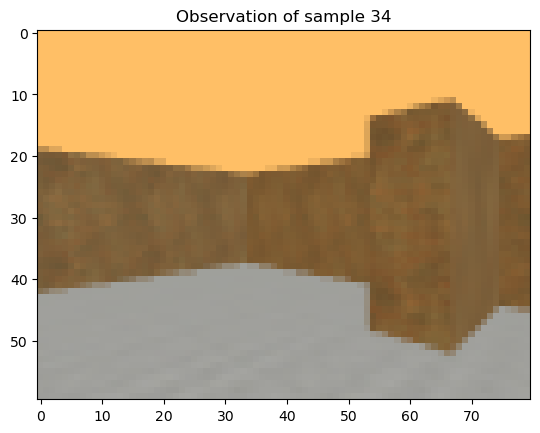

In [15]:
idx = 34 # sample index, should be in range [0, N-1]

print(f'Action of sample {idx}:                    ', actions[idx])
print(f'Time id when sample {idx} was recorded:    ', time_ids[idx])

plt.imshow(observations[idx])
plt.title(f'Observation of sample {idx}');

print(observations.shape)

Note that the observation is just a low-resolution image of the simulated environment.

An action (label) is simply an integer. The three possible action values are:

In [16]:
ACTION_LEFT = 0  # Turn left
ACTION_RIGHT = 1 # Turn right
ACTION_FORWARD = 2  # Move forward

You can use the demonstration data to train and validate your machine learning methods.
Of course, you would first need to define some feature extraction procedure(s) to convert the observations into some suitable feature vectors for your machine learning techniques.

### Replay demonstrations

The following cell allows you to replay some of the demonstrations found in the dataset.

Study the demonstrations. 

 - Are you able to recognize a specific strategy employed by the human demonstrator to solve this environment? 
 - What would happen if different strategies were employed by the demonstrator? How does this relate to *irreducible error*?

If you were to collect demonstrations yourself, these are questions that you should take into account.

In [17]:
from matplotlib import animation
from IPython.display import HTML, display, clear_output
import ipywidgets


class ReplayDemos(animation.FuncAnimation):
    def __init__(self, demo_id):
        # np array with shape (frames, height, width, channels)
        self.video_init = np.array(complete_demonstrations[demo_id]['observations'])
        
        # Add black frames at the end of the video
        length_end = 20
        self.end_video = np.zeros(np.append(length_end, self.video_init.shape[1:]), dtype=np.int32)
        self.video = np.append(self.video_init, self.end_video, axis=0)
        
        # Create figure
        self.fig = plt.figure()
        self.im = plt.imshow(self.video[0,:,:,:])
        
        plt.title('Replaying demonstration %i' % demo_id)
        plt.close() # this is required to not display the generated image
        
        # Init parent
        super().__init__(self.fig, self.animate, init_func=self.init, frames=self.video.shape[0], interval=50)
        
    def init(self):
        self.im.set_data(self.video[0,:,:,:])

    def animate(self, i):
        self.im.set_data(self.video[i,:,:,:])
        return self.im


def filter_demos(demonstrations, thr=50):
    # Remove all short demonstrations
    complete_demonstrations = []
    for demo in demonstrations:
        if demo['observations'].shape[0] > thr:
            complete_demonstrations.append(demo)
            
    return complete_demonstrations

complete_demonstrations = filter_demos(demonstrations, thr=50)

def replay_function(demo_id):
    clear_output(wait=True)
    replay_demos = ReplayDemos(demo_id)
    display(HTML(replay_demos.to_html5_video()))

ipywidgets.interactive(replay_function, demo_id=(0,len(complete_demonstrations)-1), continuous_update=False)

interactive(children=(IntSlider(value=24, description='demo_id', max=49), Output()), _dom_classes=('widget-int…

## Testing your model in  the simulator


At some point, *after you have trained and evaluated your classifier*, you might want to check how well your classification method can actually control the robot. For this, you will need to wrap your trained classifier into a policy function that the simulator can use.

This section will go over the details of
* how to start the simulator;
* how to implement a policy `policy`;
* how to analyse the rewards.


### Running a simulation

The function `run_simulation` below will setup a simulation of your robot on a given environment (`env`) and will use the policy `policy` you provide to control the robot, for a maximum of `max_steps` simulation steps. The previously created environments `env = WallGap(time_id, max_episode_steps=1000, rendering=False)` determine the environment and whether the simulation is shown in a popup-window. The simulation function can also record all the (observation, actions) pairs (`record_data=True`).

The function signature of `run_simulation` is:
```python
rewards = run_simulation(policy, env, max_steps=500, verbose=1, record_data=False, delay=0.0, seed=-1, human_control=False)
    """ Run robot simulation
    Input arguments:
    - policy        # [function] the robot's policy function
    - env           # [instance of WallGap] the environment to simulate
    - record_data   # [True/False] if true, return all (observation, action) pairs from the simulation
    - max_steps     # [int] the maximum number of steps N to run the simulation
    - delay         # [float] a time delay that can be added to make the simulation run a bit slower
    - seed          # [int] location generation random seed - only set if >=0
    - verbose       # [int] how much text gets printed: 0 = none, 1 = final stats, 2 = all
    - human_control # [True/False] if true the key presses will be passed on the policy
    
    Returns:
    - rewards       # [numpy array of floats] all N rewards accumulated during the simulation
    - observations  # [numpy array N x H x W x 3] N observations, each observation being a WxH 3-channel image
    - actions       # [numpy array of ints] all N actions outputted by the given policy f
    
    Note: `observations` and `actions` are only returned if record_data=True
    """ 
```


In [18]:
# user key input handler
from pyglet.window import key
import time

# keep track of which keys have been pressed in the popup window
# (will be used later for the human control)
KEY_PRESSED = {key.LEFT: False, key.RIGHT: False, key.UP: False}

# define the set of all actions    
ACTIONS = [0, 1, 2]
ACTION_NAMES = ['turn_left', 'turn_right', 'move_forward']
NUM_ACTIONS = 3 # number of distinct actions

def run_simulation(policy, env, max_steps=500, verbose=1, record_data=False, delay=0.0, seed=-1, human_control=False):
    """ Run robot simulation
    Input arguments:
    - policy        # [function] the robot's policy function
    - env           # [instance of WallGap] the environment to simulate
    - record_data   # [True/False] if true, return all (observation, action) pairs from the simulation
    - max_steps     # [int] the maximum number of steps N to run the simulation
    - delay         # [float] a time delay that can be added to make the simulation run a bit slower
    - seed          # [int] location generation random seed - only set if >=0
    - verbose       # [int] how much texts gets printed: 0 = none, 1 = final stats, 2 = all
    - human_control # [True/False] if true the key presses will be passed on the policy
    
    Returns:
    - rewards       # [numpy array of floats] all N rewards accumulated during the simulation
    - observations  # [numpy array N x H x W x 3] N observations, each observation being a WxH 3-channel image
    - actions       # [numpy array of ints] all N actions outputted by the given policy f
    
    Note: `observations` and `actions` are only returned if record_data=True
    """
    
    if verbose > 0:
        print(f'Starting simulation for {max_steps} steps.')
        if env.rendering:
            print('*** Press ESC key in popup window to stop the simulation! ***')
        print()

    if seed>=0:
#         env.seed(seed)
        env.reset(seed=seed)
    else:
#         env.seed(int( time.time() * 1000.0 ))
        env.reset(seed=int( time.time() * 1000.0 ))

    rewards = [] # will store the accumulated rewards
    observations = [] # will store the accumulated observations (only if record_data==True)
    actions = [] # will store the accumulated actions outputted by policy f (only if record_data==True)

    completed_steps = 0   
    
    
    try:
        # reset the simulation, and get the initial observation (robot "sensor measurement")
        obs = env.reinit(max_steps, wait_for_keypress=human_control)[0]
        
        # main simulation loop
        for step in range(max_steps):
            time.sleep(delay)
               
            if env.rendering:
                env.render()
            
            # get keyboard pressed button status from environment
            KEY_PRESSED.update(env.key_pressed)

            if env.stop_simulation: break
            
                
            # ** APPLYING YOUR POLICY **
            # execute the given policy on the observation to determine the robot's action
            action = policy(obs)
            
            # sanity check: is the policy implemented correctly?
            assert (isinstance(action, (int, np.integer))) # returned action should be a builtin or numpy integer
            assert (action in ACTIONS) # action should be an integer 0, 1, 2 or 3
            
            if verbose > 1:
                print(f'step {step}: action = {ACTION_NAMES[action]}')

            if record_data:
                # only store all the observation and action pairs during the simulation
                #   if the record_data argument is set to True
                observations.append(obs)
                actions.append(action)

            # execute simulation step with the given control input
            obs, reward, environment_done, truncation, info = env.step(action)
            completed_steps += 1
            
            if verbose > 1:
                print(f'step {step}: reward = {reward}')

            # collect all rewards in a list
            rewards.append(reward)

            # exit simulation when goal is reached
            if environment_done or truncation:
                break

    finally:
        # close the pop-up window,
        if env.rendering:
            env.close()
            env.window = None
        
    rewards = np.array(rewards)
    total_reward = np.sum(rewards)
    
    if verbose > 0:
        print(f'total reward after {completed_steps} steps: {total_reward}')
        print(f'average reward: {total_reward/completed_steps}')
    
    if record_data:
        return rewards, np.array(observations), np.array(actions, dtype=int), truncation
    
    # by default, only return the rewards
    return rewards

The function `test_policy` below will run the `policy` in given environment (`env`) for a number `num_runs` different initial configurations. This function ensures that always the same set of configurations is used, allowing you to reproducibly compare the performance of different policies.

The function signature of `test_policy` is:
```python
num_completed, avg_reward = test_policy(policy, env, verbose=0, num_runs=10)
    """ Test a policy
    Input arguments:
    - policy        # [function] the robot's policy function
    - env           # [instance of WallGap] the environment to simulate
    - verbose       # [int] how much text gets printed: 0 = none, 1 = final stats, 2 = all
    - num_runs       # [int] how many configurations to evaluate
    
    Returns:
    - num_completed  # [int] number of runs in which the goal was reached
    - avg_reward    # [float] average reward over the runs
    """ 
```

In [19]:
def test_policy(policy, env, verbose=0, num_runs=10):
    """ Test a policy
    Input arguments:
    - policy        # [function] the robot's policy function
    - env           # [instance of WallGap] the environment to simulate
    - verbose       # [int] how much text gets printed: 0 = none, 1 = final stats, 2 = all
    - num_runs       # [int] how many configurations to evaluate
    
    Returns:
    - num_completed  # [int] number of runs in which the goal was reached
    - avg_reward    # [float] average reward over the runs
    """ 
    
    num_completed = 0
    avg_reward = 0.0
  
    seeds = range(0,num_runs)
    run_count = 1
    for seed in seeds:
        print('Run %i / %i' % (run_count, num_runs))
        success = False
        run_count += 1
        rs = run_simulation(
            policy,
            env,
            record_data=False,
            verbose=verbose, 
            max_steps=300, 
            delay=0.0,
            seed=seed)

        avg_reward += np.mean(rs)
        if np.sum(rs) > 0:
            num_completed += 1
            success = True
            
        print('Success:', success)
    
    avg_reward /= float(num_runs)
    
    print()
    print(f'average reward: {avg_reward}')
    print(f'reached target: {num_completed} / {num_runs}')
    
    return num_completed, avg_reward

### Implementing a policy

For the simulator, $policy(observation) \rightarrow action$ should be implemented as a plain python function which takes a numpy array as input (the observation) and returns an integer (the action).
So generally, a policy implementation would look like this:


```python
def policy(observation):    
    """
    Input: observation, a H x W x 3 numpy array containing an RGB image of the surroundings
    Output: action,     an integer representing the action (0 = Left, ... 2 = Forward)
    N.B.: actions is just an int, NOT a numpy array
    """ 
    
    # YOUR CODE
    #   convert observation to feature vector
    #   predict action class given the feature vector using some ML technique
    
    return action
```
*Of course, don't name you policy just `policy`, but give it some more descriptive name!*

To illustrate, here is a dummy policy which just picks a random actions (without actually looking at the observation).

In [20]:
# a dummy policy
def policy_dummy(observation):
    """ Dummy policy function, which just returns random action. 
    
    Input: observation, a H x W x 3 numpy array containing an RGB image of the surroundings
    Output: action,     an integer representing the action (0 = Left, ... 2 = Forward)
    N.B.: actions is just an int, NOT a numpy array
    """
    
    # in this dummy policy, we ignore the observation and just select a random action
    action = np.random.randint(0, NUM_ACTIONS)
    
    # print(f'Received observation: {observation.shape} numpy array of type {observation.dtype}, returning action {action}')
    return action

We can confirm that the policy returns a valid action label:

In [21]:
action = policy_dummy(observations)

# returned action should be a builtin int or a numpy integer (NOT a numpy array) in the range [0, 4]
assert (isinstance(action, (int, np.integer)))
assert (action in ACTIONS) # ACTIONS is the set of possible action labels, [0,1,2,3,4]

### Reward

To quantify how well a policy is working, the simulator will return the *rewards* that the robot collected at each simulation step. The rewards determine how well you are doing, and are based on whether or not you reach the target (red cube) or not and how quickly you do so:

* The robot receives a reward of 0 when not reaching the target within the given maximum number of steps.
* The robot receives a reward of 1 when reaching the target, at which time also the episode ends. The robot also gets a small malus for the number of steps it needs to reach the target, as a penalty for spending time. 
* The equation for this is: $ 1.0 - 0.2 * (step\_count / max\_episode\_steps)$ 

Overall, the goal is to reach the red cube as quickly as possible.

### Illustration of running the simulator with the dummy policy

Let's try to run the simulation with the dummy policy, and render the output in the popup-window for 100 steps.

In [22]:
time_id = 1 # <-- CHANGE THIS to select the time; can be 0, 1, 2

if show_policy:
    # running the simulation with the dummy policy
    rs = run_simulation(policy_dummy, envs[time_id], max_steps=100)

Starting simulation for 100 steps.

total reward after 100 steps: -0.8700000000000001
average reward: -0.008700000000000001


Clearly, this policy does not do anything particularly useful, and should make the robot just move around randomly. Let's visualize the rewards that the robot collected during the simulation.

The first plot below shows when the reward is collected. The second plot shows the total/cumulative reward. You will probably see two flat lines as the dummy policy did not accumulate any rewards. This is indicative of a bad policy.

Average reward: 0.0


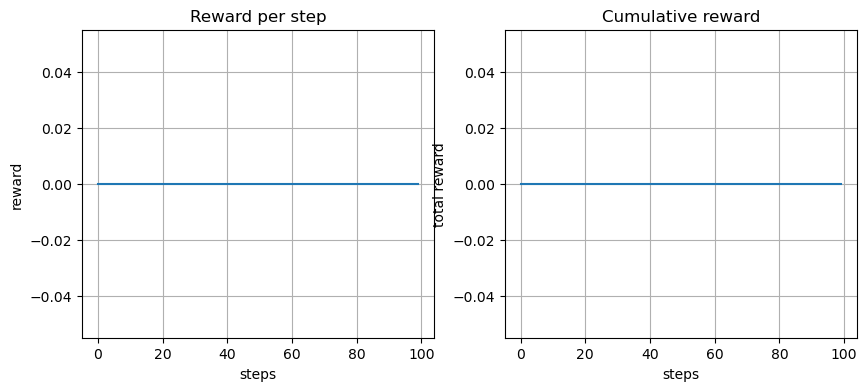

In [20]:
if show_policy:
    plt.figure(figsize=(10,4)) # create a wide figure (size 10) which is not so tall (size 4)
    plt.subplot(1,2,1) # create subplot of 1 row, 2 columns, enable plotting in first cell
    plt.plot(rs)
    plt.xlabel('steps')
    plt.ylabel('reward')
    plt.title('Reward per step')
    plt.grid()

    plt.subplot(1,2,2) # create subplot of 1 row, 2 columns, enable plotting in first cell
    plt.plot(np.cumsum(rs)) # Cumulative sum of rewards
    plt.xlabel('steps')
    plt.ylabel('total reward')
    plt.title('Cumulative reward')
    plt.grid()

    print('Average reward:', np.mean(rs))

For comparing and evaluating classifiers, measure the performance of the classifiers themselves, i.e., the macro-F1 score.

Still, the simulation and rewards can help you assess in what situations your robot AI is performing well, and when it is failing. For this use the function `test_policy`, with the default 10 runs.

In [21]:
num_completed, avg_reward = test_policy(policy_dummy, envs_norender[time_id])

Run 1 / 10
Success: False
Run 2 / 10
Success: False
Run 3 / 10
Success: False
Run 4 / 10
Success: False
Run 5 / 10
Success: False
Run 6 / 10
Success: False
Run 7 / 10
Success: False
Run 8 / 10
Success: False
Run 9 / 10
Success: False
Run 10 / 10
Success: False

average reward: 0.0
reached target: 0 / 10


# Collecting new demonstrations

At some point, you might want to collect more human demonstration data to make your method even better.
You can do this by:

- manually controlling the robot in the simulation yourself to generate new demonstrations
- recording the resulting (observation, action) pairs during these demonstrations
- saving the good demonstrations to disk to increase your example dataset

The code below demonstrates how to do this. The idea is simple: just use the regular `run_simulation()` function, but use a special `policy_human()` policy which simply returns the action based on the keyboard input!

In [22]:
# a human
def policy_human(observation):
    # Get the action obtained by the key_press/key_release callbacks from the popup window.
    # Note that the human demonstrator (you!) will of course see the environment image in the popup window,
    # and ignore the 'observation' input of this function.
    # This 'human policy' will therefore return your 'action' response to the visual input by checking
    # which keyboard arrows you pressed.
    # Note 1: As we don't have an idle action, the time will only progress when you press a key
    # Note 2: If you press and key except the arrow keys or ESC, the policy sanity check will fail

    if KEY_PRESSED[key.LEFT]: return ACTIONS[0]
    elif KEY_PRESSED[key.RIGHT]: return ACTIONS[1]
    elif KEY_PRESSED[key.UP]: return ACTIONS[2]

When we use this policy, ensure that the simulator stores and returns all the (observation, action) pairs by setting the `record_data` argument of run_simulation to `True`.
You can adjust the `time_id` to get human demonstrations at a variety of times during the day for the training environment. If you want a reproducible initial configuration, you can also set a `seed`.

In [23]:
if collect_demo:
    time_id = 0 # <-- CHANGE THIS to select the time; can be 0, 1, 2
    # NOTE: if an interactive widget is active, this simulation will run slower

    rs, rec_obs, rec_actions, truncation = run_simulation(
        policy_human,          # by using the 'human' policy, YOU determine the robot's actions based on what you see
        record_data=True,      # record and return all (observation, action) pairs from the simulation 
        env=envs[time_id],     # which environment to use
        max_steps=1000,        # maximum number of steps to run the simulation
        human_control=True,    # when controlling the robot manually
        delay=0.1,            # adding a small delay will help you control the robot
    )
    # Note: with delay=0.05 the simulation runs a bit slower, which makes it easier to give demonstrations
    
else:
    rec_obs = observations
    rec_actions = actions
    truncation = False

Starting simulation for 1000 steps.
*** Press ESC key in popup window to stop the simulation! ***

total reward after 10 steps: 0
average reward: 0.0


Explore the just collected samples using an interactive slider (if you didn't collect new data you'll explore the pre-recoded demonstrations instead)

In [24]:
def plot_sample(idx, observations, actions):
    obs = observations[idx]
    action = actions[idx]
    plt.clf()
    plt.imshow(obs)
    plt.title(f'{idx}: {action}');

ipywidgets.interactive(lambda idx: plot_sample(idx, rec_obs, rec_actions),
                       idx=(0,rec_obs.shape[0]-1))

interactive(children=(IntSlider(value=4, description='idx', max=9), Output()), _dom_classes=('widget-interact'…

If you are unhappy with the the demonstration you gave, you can just execute the `run_simulation()` cell above again, until you are satisfied.

To save the demonstration to disk, execute the cell below after setting `SAVE_DEMO` to True.

**After you have saved the demonstration, don't forget to afterwards IMMEDIATELY set `SAVE_DEMO` back to False to avoid accidentally saving new demonstrations every time you rerun the notebook!!!**

Note that the pickle filenames of your recordings will start with `demostud-`, while the originally provided demonstrations start with `demo-`. This makes it easy to load only the original, your, or both types of recordings.

In [25]:
SAVE_DEMO = False # <-- CHANGE THIS to 'True' to SAVE the last recording to disk!

if SAVE_DEMO and not truncation: 
    rec_N = rec_obs.shape[0]

    demonstration = {
        'observations': rec_obs,
        'actions': rec_actions,
        'time': time_id * np.ones(rec_N, dtype=int),
    }
    
    # include date+time to filename in YYYYMMDD_HHMMSS format
    import datetime
    now = datetime.datetime.now()
    dt_str = now.strftime('%Y%m%d_%H%M%S')

    # Save to disk
    save_filename = f'demonstrations/demostud-{time_id}-{dt_str}.pickle'
    print(f'Saving demonstration of time {time_id} to {save_filename} ...')
    with open(save_filename, 'wb') as fd:
        pickle.dump(demonstration, fd)
elif SAVE_DEMO and truncation:
    print('Recording was truncated, not saving the demonstration to disk.')

Ok, that completes the example code.
Now it is your turn! Implement your solution to the final assignment below. For full points, make sure you address *all* the numbered items for each section, either by implementing something in code cells, or by providing text in Markdown cells. You are free to add as many code and markdown cells as required. Be sure to first read through all sections before you start, so you know what should go where. We are *not* using nbgrader for this final assignment.

**When you are done, double check the "Deliverables" section at the start of this notebook on how to prepare your final submission!**

Good luck!


---

# 1. Explore & Inspect the Data (5 points)
In this section you should only use the ORIGINALLY provided demo files (i.e. 'demo-*-*.pickle')

Add code and markdown cells to address all of the following points:

1. Create a visualization that shows three samples from each time of day for which you have demonstrations. <span style="float: right;">(0.5 pt)</span>
2. Explain in words what you observe: how do the observations from the times of day vary? <span style="float: right;">(0.5 pt)</span>
3. Are the samples i.i.d.? What does that imply for splitting your data? <span style="float: right;">(1 pt)</span>
4. Is there a class imbalance? If yes, what are procedures to deal with that? <span style="float: right;">(1 pt)</span>
5. Do we have a high risk of conflicting labels for observations? What problems can this cause? <span style="float: right;">(1 pt)</span>
6. The data was collected from human demonstrations. What are potential issues with this way of collecting data? <span style="float: right;">(1 pt)</span>

 

In [91]:
demo_files = glob.glob(f'demonstrations/{DEMO_FILEPATTERN}')
demo_files.sort()
demo_files_0 = [f for f in demo_files if f.split('-')[1] == '0']
demo_files_1 = [f for f in demo_files if f.split('-')[1] == '1']
demo_files_2 = [f for f in demo_files if f.split('-')[1] == '2']

demo_files = [demo_files_0, demo_files_1, demo_files_2]

def plot_three_samples(idx0, idx1, idx2, demo_files):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    with open(demo_files[0][idx0], 'rb') as fd:
        demo0 = pickle.load(fd)
    with open(demo_files[1][idx1], 'rb') as fd:
        demo1 = pickle.load(fd)
    with open(demo_files[2][idx2], 'rb') as fd:
        demo2 = pickle.load(fd)

    plt.imshow(demo0['observations'][0])
    plt.title(f'Time 0, {demo0["actions"].shape[0]} samples')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(demo1['observations'][0])
    plt.title(f'Time 1, {demo1["actions"].shape[0]} samples')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(demo2['observations'][0])
    plt.title(f'Time 2, {demo2["actions"].shape[0]} samples')
    plt.axis('off')

ipywidgets.interactive(plot_three_samples, idx0=(0,len(demo_files_0)-1), idx1=(0,len(demo_files_1)-1), idx2=(0,len(demo_files_2)-1), demo_files=ipywidgets.fixed(demo_files))


interactive(children=(IntSlider(value=11, description='idx0', max=23), IntSlider(value=9, description='idx1', …

Observations:

The environment is the same, except for the colors of the different objects. The floors are regular, the walls always have the same angle and height. The textures of the walls and floor are different. At each time of day, the floors, walls and goal still have a strong color gradient to each other. Let's plot the same thing, but after converting the colors to grayscale. 

In [24]:
def plot_three_samples_grayscale(idx0, idx1, idx2, demo_files):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    with open(demo_files[0][idx0], 'rb') as fd:
        demo0 = pickle.load(fd)
    with open(demo_files[1][idx1], 'rb') as fd:
        demo1 = pickle.load(fd)
    with open(demo_files[2][idx2], 'rb') as fd:
        demo2 = pickle.load(fd)

    plt.imshow(demo0['observations'][0].mean(axis=-1), cmap='gray')
    plt.title(f'Time 0, {demo0["actions"].shape[0]} samples')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(demo1['observations'][0].mean(axis=-1), cmap='gray')
    plt.title(f'Time 1, {demo1["actions"].shape[0]} samples')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(demo2['observations'][0].mean(axis=-1), cmap='gray')
    plt.title(f'Time 2, {demo2["actions"].shape[0]} samples')
    plt.axis('off')

ipywidgets.interactive(plot_three_samples_grayscale, idx0=(0,len(demo_files_0)-1), idx1=(0,len(demo_files_1)-1), idx2=(0,len(demo_files_2)-1), demo_files=ipywidgets.fixed(demo_files))

interactive(children=(IntSlider(value=11, description='idx0', max=23), IntSlider(value=9, description='idx1', …

From the gray images, it becomes clear that we will need to use more sophisticated methods to reduce the dimensionality. 

The samples within observations are obviously dependent, so the training/validation/testing split should be split over observations. 
E.g., if we have 10 observations with each some number of actions, then the training set should have 8 of those observations, the validation set one observation, and the testing set one final observation, assuming an 8:1:1 split. Care should also be taken to include all times of day in each set, if possible, to ensure that any feature extraction methods work in each situation. 

Let's examine the classes. 

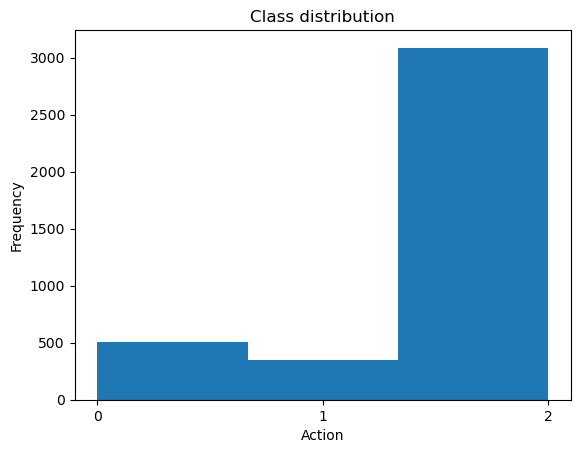

In [28]:
classes = np.unique(actions)

def plot_class_distribution(actions):
    plt.hist(actions, bins=classes.size)
    plt.xticks(classes)
    plt.xlabel('Action')
    plt.ylabel('Frequency')
    plt.title('Class distribution')

plot_class_distribution(actions)

Clearly, action of type '2', or moving forward, is heavily overrepresented. This can be accounted for in a few ways. 

- Undersampling: not using all the samples of class 2. 
- Oversampling: duplicating samples of the underrepresented classes, or generating synthetic samples using SMOTE (Fernández, A., Garcia, S., Herrera, F., & Chawla, N. V. (2018). SMOTE for learning from imbalanced data: progress and challenges, marking the 15-year anniversary. Journal of artificial intelligence research, 61, 863-905.)
- Using a weighted loss function that favors the less frequent labels.
- Simulate with a higher forward speed so that fewer 'forward' steps are needed, or, after generating the full demonstration, throw away 1 in n samples of long forward trajectories to undersample in a more targeted way. 


In some of the videos, it can be seen that the demonstration strategy is not always consistent. Sometimes, the robot starts by turning right, other times it starts turning left, even if the robot is facing the right side of a corner (and thus a right turn would be more efficient). This means that for a given observation a, there can be a label 0 and a label 1. If this is left in the dataset, the model will optimize in two directions, and thus fail to optimize at all. 

Collecting data through human input has some issues:

- It is relatively expensive compared to how much data can be generated
- Humans can make mistakes, especially when generating the data is very repetitive

On the other hand, creating the data for this kind of task automatically can become quite complex, especially when the environment or problem is expanded. The point of making this kind of model is because it is apparently infeasible to create a robot using traditional logic to complete the task. 

The human dataset can be expanded with data generated during early iterations of the training process by selecting succesful runs on newly generated scenarios as input to new training loops, marking succesful runs as those with a similar average reward as the ones generated by humans. However, this does increase the risk of overfitting.

---

# 2. Prepare the Data and Evaluate Features (15 points)

In this section you should only use the ORIGINALLY provided demo files (i.e. 'demo-*-*.pickle'). You should pre-process the data, e.g., down-sample, and extract features to create your training data matrix "X".

<div class="alert alert-block alert-warning">
Remember to provide thorough insights, analysis and reasoning behind your design choices and what you see as a consequence of these choices. Try to synthesize rather than describing what you did step by step.
</div>

## 2.1. Clustering observations from times of day (6 points)

Before we turn towards the main task of action classification (section 2.2), let us first try a small unsupervised clustering task. Pretend that we only have the observations, but did not record the time_ids of these observations. The goal is to cluster the observations into k=3 clusters such that 1 cluster (approximately) corresponds to 1 time of day. For this task, you can ignore the actions and time_id information.

1. Propose a feature extraction method `feat_extract_clust` which can be used to CLUSTER the samples and (approximately)<br> recover the time_ids. Motivate what you use in your feature extraction method. <span style="float: right;">(2 pt)</span>
2. Perform clustering based on the features obtained with `feat_extract_clust`, and compare the results to the true time_id<br> labels. For this you will need to select a statistical measure to compare cluster labels to time_ids. <span style="float: right;">(1 pt)</span> (Please refer to [this link](https://scikit-learn.org/stable/modules/model_evaluation.html))
3. Explain what measure you use for comparing the features and why. <span style="float: right;">(2 pt)</span>
4. Can you recover the time_ids by clustering? Motivate your answer with your results. <span style="float: right;">(1 pt)</span>

For science, we can just try all the features we can think of. That is, anything color related that we can extract, since we know that the time label is easily identifiable by color. Then, apply PCA, find which features have the most impact on the most impactful components, and use those features for our clustering. 

Original feature space: 39 dimensions
PCA feature space: 6 dimensions


Text(0.5, 1.0, 'Explained variance ratio per principal component')

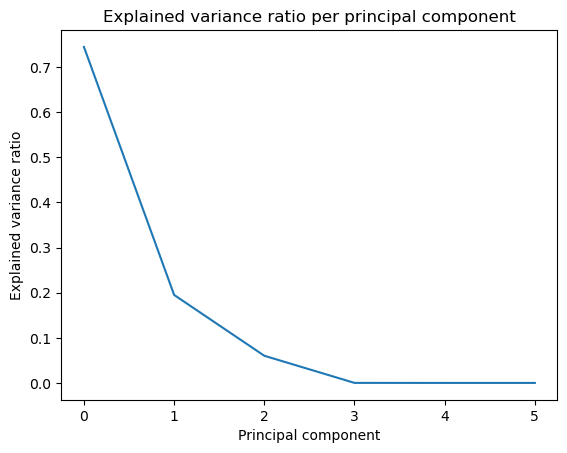

In [25]:
def extract_features(observation):
    """ Extract features from the observation
    Input: observation, a H x W x 3 numpy array containing an RGB image of the surroundings
    Output: features, a D-dimensional numpy array
    """
    I_mean = observation.mean(axis=(0,1)).mean()
    I_std = observation.std(axis=(0,1)).mean()
    I_var = observation.var(axis=(0,1)).mean()
    I_max = observation.max(axis=(0,1)).mean()
    I_min = observation.min(axis=(0,1)).mean()
    I_median = np.median(observation, axis=(0,1)).mean()
    I_sum = observation.sum(axis=(0,1)).mean()
    I_diff = np.diff(observation, axis=0).mean(axis=(0,1)).mean()
    I_diff2 = np.diff(observation, axis=1).mean(axis=(0,1)).mean()
    I_R_mean = observation[:,:,0].mean().mean()
    I_G_mean = observation[:,:,1].mean().mean()
    I_B_mean = observation[:,:,2].mean().mean()
    I_R_std = observation[:,:,0].std().mean()
    I_G_std = observation[:,:,1].std().mean()
    I_B_std = observation[:,:,2].std().mean()
    I_R_var = observation[:,:,0].var().mean()
    I_G_var = observation[:,:,1].var().mean()
    I_B_var = observation[:,:,2].var().mean()
    I_R_max = observation[:,:,0].max().mean()
    I_G_max = observation[:,:,1].max().mean()
    I_B_max = observation[:,:,2].max().mean()
    I_R_min = observation[:,:,0].min().mean()
    I_G_min = observation[:,:,1].min().mean()
    I_B_min = observation[:,:,2].min().mean()
    I_R_median = np.median(observation[:,:,0]).mean()
    I_G_median = np.median(observation[:,:,1]).mean()
    I_B_median = np.median(observation[:,:,2]).mean()
    I_R_sum = observation[:,:,0].sum().mean()
    I_G_sum = observation[:,:,1].sum().mean()
    I_B_sum = observation[:,:,2].sum().mean()
    I_R_diff = np.diff(observation[:,:,0]).mean().mean()
    I_G_diff = np.diff(observation[:,:,1]).mean().mean()
    I_B_diff = np.diff(observation[:,:,2]).mean().mean()
    I_R_diff2 = np.diff(observation[:,:,0], axis=0).mean().mean()
    I_G_diff2 = np.diff(observation[:,:,1], axis=0).mean().mean()
    I_B_diff2 = np.diff(observation[:,:,2], axis=0).mean().mean()
    I_R_diff3 = np.diff(observation[:,:,0], axis=1).mean().mean()
    I_G_diff3 = np.diff(observation[:,:,1], axis=1).mean().mean()
    I_B_diff3 = np.diff(observation[:,:,2], axis=1).mean().mean()

    features = np.array([I_mean, I_std, I_var, I_max, I_min, I_median, I_sum, I_diff, I_diff2, I_R_mean,
                            I_G_mean, I_B_mean, I_R_std, I_G_std, I_B_std, I_R_var, I_G_var, I_B_var, I_R_max, I_G_max,
                            I_B_max, I_R_min, I_G_min, I_B_min, I_R_median, I_G_median, I_B_median, I_R_sum, I_G_sum, I_B_sum,
                            I_R_diff, I_G_diff, I_B_diff, I_R_diff2, I_G_diff2, I_B_diff2, I_R_diff3, I_G_diff3, I_B_diff3])
    return features

# extract features from all observations
features = np.array([extract_features(obs) for obs in observations])

# Apply PCA to reduce the dimensionality of the feature space
from sklearn.decomposition import PCA

# number of components to keep
n_components = 6

pca = PCA(n_components=n_components)
features_pca = pca.fit_transform(features)

print(f'Original feature space: {features.shape[1]} dimensions')
print(f'PCA feature space: {features_pca.shape[1]} dimensions')

# plot the explained variance ratio
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title('Explained variance ratio per principal component')


It seems like 2 components might be enough. 

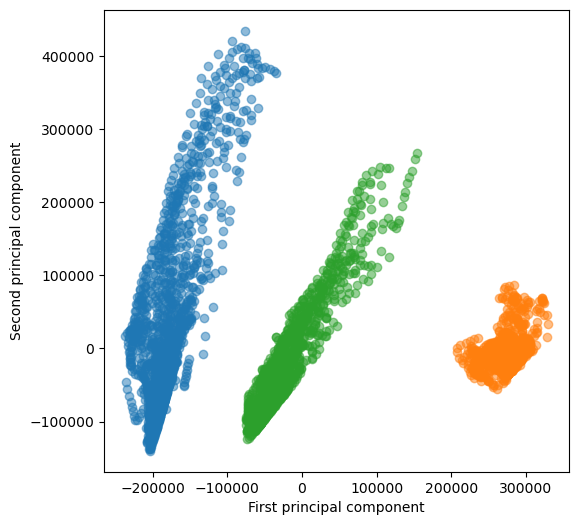

In [26]:

# Select the first two principal components
features_2d = features_pca[:,:2]

# Plot the clusters with the labels of the times
plt.figure(figsize=(6, 6))
for time_id in range(3):
    plt.scatter(features_2d[time_ids == time_id, 0], features_2d[time_ids == time_id, 1], alpha=0.5, label=f'Time {time_id}')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.show()

This seems promising. The next step is to find which features contribute a lot to these two PCA components. 

39
39
[0.12928973 0.17280975 0.45237069 0.58463057 0.35762187]


Text(0.5, 1.0, 'Loadings of the first two principal components')

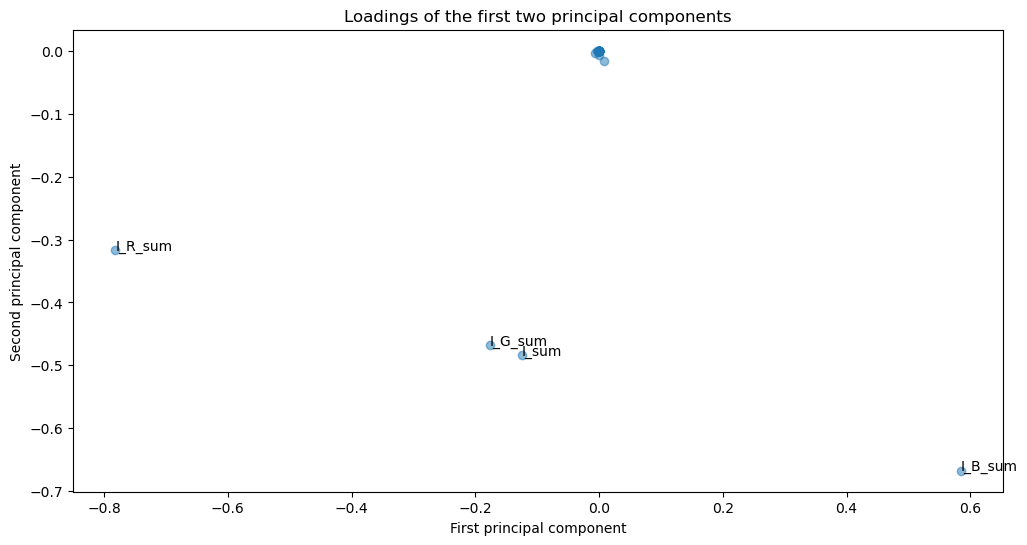

In [27]:

import matplotlib.pyplot as plt
import numpy as np

# Assuming `feature_names` is a list of your feature names
feature_names = [
    'I_mean', 'I_std', 'I_var', 'I_max', 'I_min', 'I_median', 'I_sum', 
    'I_diff', 'I_diff2', 'I_R_mean', 'I_G_mean', 'I_B_mean', 'I_R_std', 
    'I_G_std', 'I_B_std', 'I_R_var', 'I_G_var', 'I_B_var', 'I_R_max', 
    'I_G_max', 'I_B_max', 'I_R_min', 'I_G_min', 'I_B_min', 'I_R_median', 
    'I_G_median', 'I_B_median', 'I_R_sum', 'I_G_sum', 'I_B_sum', 'I_R_diff', 
    'I_G_diff', 'I_B_diff', 'I_R_diff2', 'I_G_diff2', 'I_B_diff2', 'I_R_diff3', 
    'I_G_diff3', 'I_B_diff3'
]

loadings = pca.components_.T  # Transpose to align features with components

print(len(feature_names))
print(len(loadings))

print(loadings[loadings > 0.1])

# Plot the loadings of the first two principal components
plt.figure(figsize=(12, 6))
plt.scatter(loadings[:, 0], loadings[:, 1], alpha=0.5)
for i, feature_name in enumerate(feature_names):
    if np.abs(loadings[i, 0]) > 0.1 or np.abs(loadings[i, 1]) > 0.1:
        plt.text(loadings[i, 0], loadings[i, 1], feature_name) # label the points that have a high loading
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('Loadings of the first two principal components')


We could have guessed this, but it is nice to see the confirmation. We will use these features and try K-Means and GMM as we used those before.

c:\Users\danie\Documents\GitHub\handson-ml3\.conda\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


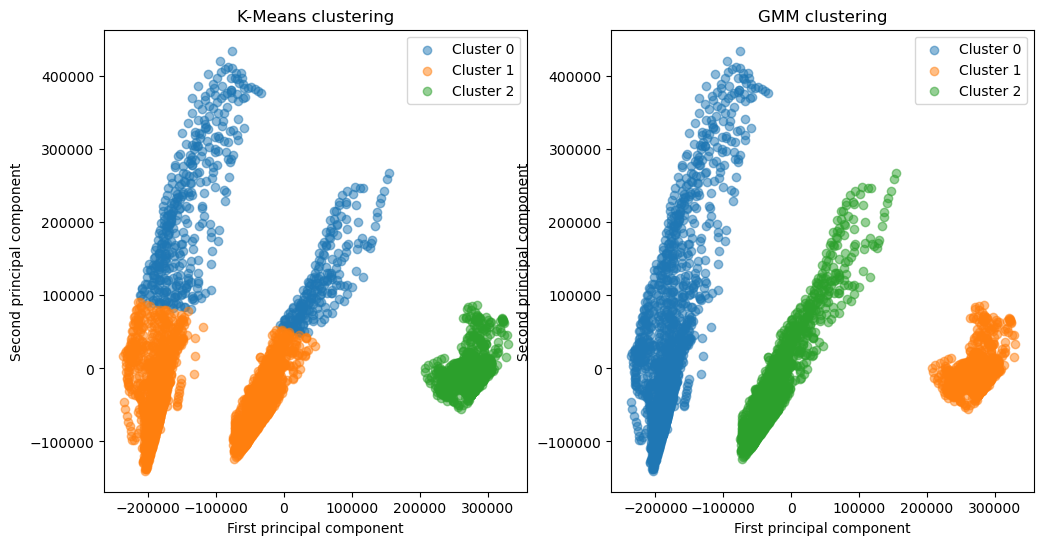

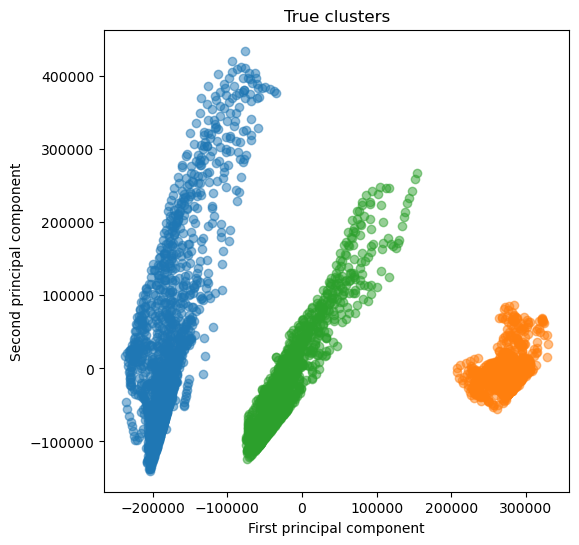

In [28]:
def extract_features(observation):
    I_sum = observation.sum(axis=(0,1)).mean()
    I_R_sum = observation[:,:,0].sum().mean()
    I_G_sum = observation[:,:,1].sum().mean()
    I_B_sum = observation[:,:,2].sum().mean()

    features = np.array([I_sum, I_R_sum, I_G_sum, I_B_sum])
    return features

# extract features from all observations
features = np.array([extract_features(obs) for obs in observations])

# Define K-Means and GMM models
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# number of clusters
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters)
gmm = GaussianMixture(n_components=n_clusters)

# Use PCA to reduce to 2 dimensions for easy visualization
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# Fit the models
kmeans.fit(features_2d)
gmm.fit(features_2d)

# Predict the clusters
kmeans_clusters = kmeans.predict(features_2d)
gmm_clusters = gmm.predict(features_2d)

# Plot the clusters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for cluster in range(n_clusters):
    plt.scatter(features_2d[kmeans_clusters == cluster, 0], features_2d[kmeans_clusters == cluster, 1], alpha=0.5, label=f'Cluster {cluster}')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('K-Means clustering')
plt.legend()

plt.subplot(1, 2, 2)
for cluster in range(n_clusters):
    plt.scatter(features_2d[gmm_clusters == cluster, 0], features_2d[gmm_clusters == cluster, 1], alpha=0.5, label=f'Cluster {cluster}')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('GMM clustering')
plt.legend()

# Plot the clusters with the labels of the times
plt.figure(figsize=(6, 6))
for time_id in range(3):
    plt.scatter(features_2d[time_ids == time_id, 0], features_2d[time_ids == time_id, 1], alpha=0.5, label=f'Time {time_id}')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('True clusters')
plt.show()



Clearly, K-Means is not suitable for this task. This is because K-Means assumes spherical and equally sized clusters, which is not the case. 

## 2.2. Features for action classification (9 points)

Now we turn to feature extraction for the main classification task, which you can reuse also in the later sections of this notebook.

1. Explain: Will you use the same extractor as in step 1; Why (not)? <span style="float: right;">(2 pt)</span>
2. Propose a feature extraction method `feat_extract` which you will use in the subsequent sections to classify *action*, rather<br> than time_ids. <span style="float: right;">(1 pt)</span>
3. Explain: Are there any important hyperparameters in your feature extractor? <span style="float: right;">(2 pt)</span>
4. Explain: How will you decide on the values for these hyperparameters? What is the trade-off if this hyperparameter is either (too)<br> low or (too) high? <span style="float: right;">(2.5 pt)</span>
5. Explain: What is the dimensionality of your feature space? <span style="float: right;">(0.5 pt)</span>
6. Apply your `feat_extract` to all observations to create the data that you will use in the subsequent sections. <span style="float: right;">(1 pt)</span>

1. We can not use the same extractor, because we now also care about specific spots in the image. We can not extract the overall redness of the image and base the required direction off of that alone, there needs to be some spacial component remaining. 
2. There are a number of feature extraction methods that we can try to solve the problem. Color is still an important feature to look at, as the box is always a distinctly different color from the rest of the environment. However, edge detection and related methods might also be useful. We can try a few different methods to see which is more effective. 
# TODO


In [29]:
import cv2
from skimage.feature import local_binary_pattern

def color_means(image, N_mean, M_mean):
    stats = []
    height, width = image.shape[:2]
    print(f"N, M: {N_mean}, {M_mean}")
    # Split image into NxM regions
    for x in range(0, height, M_mean):
        for y in range(0, width, N_mean):
            region = image[x:min(x+M_mean, height), y:min(y+N_mean, width)]
            mean = np.mean(region, axis=(0, 1))
            print(mean)
            stats.extend(mean)
    
    return np.array(stats)

def color_stds(image, N_std, M_std):
    stats = []
    height, width = image.shape[:2]
    
    # Split image into NxM regions
    for x in range(0, height, M_std):
        for y in range(0, width, N_std):
            # Ensure region does not exceed image boundaries
            region = image[x:min(x+M_std, height), y:min(y+N_std, width)]
            std = np.std(region, axis=(0, 1))
            stats.extend(std)
    
    return np.array(stats)

def edge_detection(image, low_e, high_e):
    edges = cv2.Canny(image, low_e, high_e)
    return np.sum(edges) / (image.shape[0] * image.shape[1])  # Normalized edge intensity

def color_segmentation(image):
    # Simple color thresholding for red
    lower_red = np.array([0, 0, 100])
    upper_red = np.array([100, 100, 255])
    mask = cv2.inRange(image, lower_red, upper_red)
    red_area = np.sum(mask) / 255  # Count of red pixels
    return red_area / (image.shape[0] * image.shape[1])  # Normalized red area

def texture_analysis(image, radius, n_points):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    n_points = n_points * radius
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    return hist.astype(np.float32) / (image.shape[0] * image.shape[1])  # Normalized histogram

def line_detection(image, low_l, high_l, rho, theta, threshold):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, low_l, high_l)
    lines = cv2.HoughLines(edges, rho, theta, threshold)
    return len(lines) if lines is not None else 0

def blob_detection(image):
    # Setup SimpleBlobDetector parameters
    params = cv2.SimpleBlobDetector_Params()
    params.filterByColor = True
    params.blobColor = 255  # Assuming red is bright in the image
    
    # Create a detector with the parameters
    detector = cv2.SimpleBlobDetector_create(params)
    
    # Detect blobs
    keypoints = detector.detect(image)
    
    return len(keypoints)

def extract_features(image, params):
    features = []
    features.extend(color_means(image, params["N_mean"], params["M_mean"]))
    features.extend(color_stds(image, params["N_std"], params["M_std"]))
    features.append(edge_detection(image, params["low_e"], params["high_e"]))
    # features.extend(hog_features(image, params["win_size"], params["block_size"], params["block_stride"], params["cell_size"], params["nbins"]))
    features.append(color_segmentation(image))
    features.extend(texture_analysis(image, params["radius"], params["n_points"]))
    features.append(line_detection(image, params["low_l"], params["high_l"], params["rho"], params["theta"], params["threshold"]))
    features.append(blob_detection(image))

    return np.array(features)




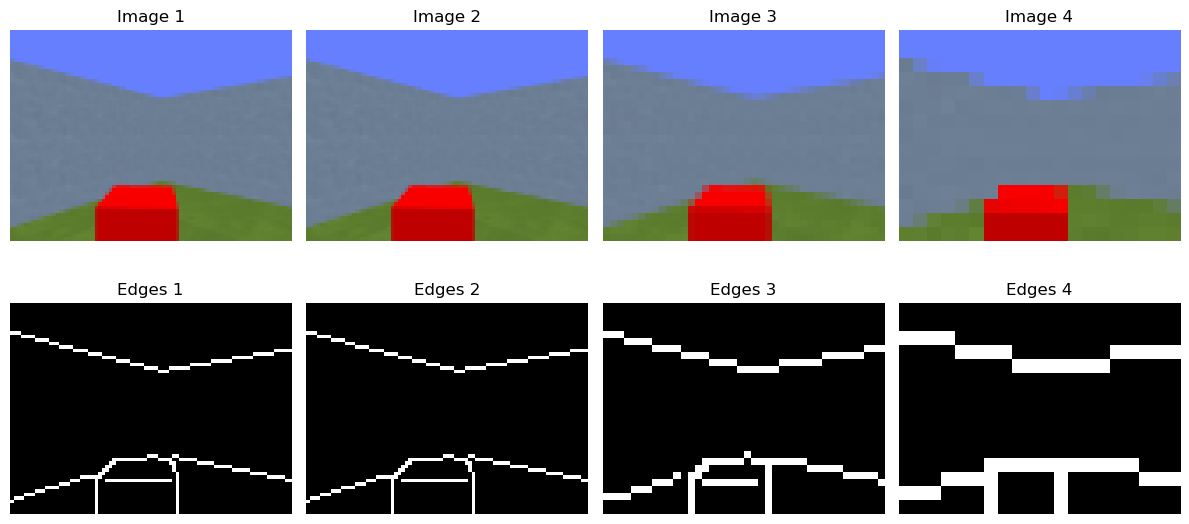

In [34]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from collections import Counter
from sklearn.utils import resample
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import ParameterGrid

# Select a random image
# np.random.seed(42)
random_idxs = np.random.choice(len(observations), 1, replace=False)
random_image = observations[random_idxs][0]

# Generate three increasingly downsampled versions of the image
downsampled_images = [cv2.resize(random_image, (random_image.shape[1] // 2**i, random_image.shape[0] // 2**i)) for i in range(3)]

# Perform canny edge detection on all four images
edges = [cv2.Canny(image, 100, 200) for image in [random_image] + downsampled_images]

# Plot the images

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, (image, edge) in enumerate(zip([random_image] + downsampled_images, edges)):
    axes[0, i].imshow(image)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Image {i+1}')
    axes[1, i].imshow(edge, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Edges {i+1}')

plt.tight_layout()





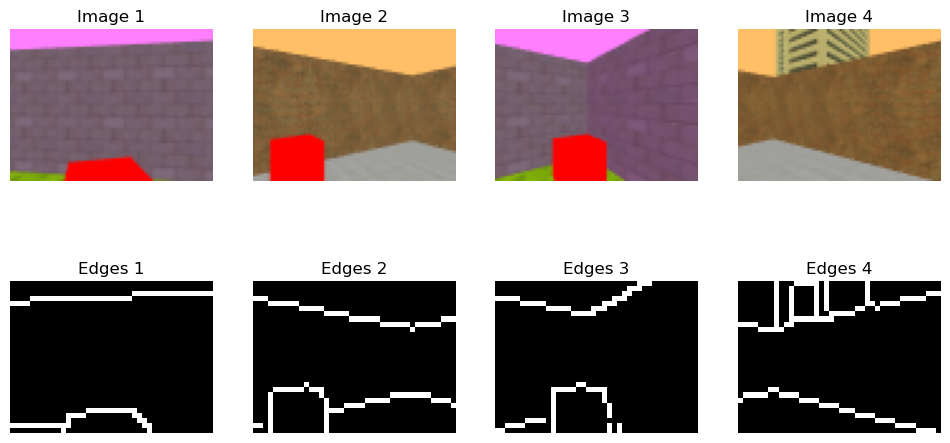

In [40]:
def downscale_and_detect_edges(image, downscale_factor=2, low_threshold=100, high_threshold=200):
    # Downscale the image
    downscale_size = (image.shape[1] // downscale_factor, image.shape[0] // downscale_factor)
    downsampled_image = cv2.resize(image, downscale_size)
    
    # Detect edges in the downsampled image
    edges = cv2.Canny(downsampled_image, low_threshold, high_threshold)
    
    return downsampled_image, edges

# Select images
random_idxs = np.random.choice(len(observations), 4, replace=False)
random_image = observations[random_idxs]

# Downscale and detect edges
downsampled_images, edges = zip(*[downscale_and_detect_edges(image) for image in random_image])

# Plot the images
fig, axes = plt.subplots(2, 4, figsize=(12, 6)) 
for i, (image, edge) in enumerate(zip(random_image, edges)):
    axes[0, i].imshow(image)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Image {i+1}')
    axes[1, i].imshow(edge, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Edges {i+1}')

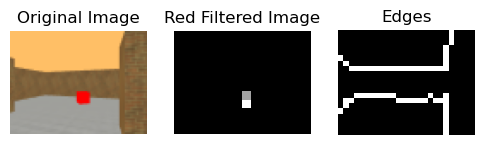

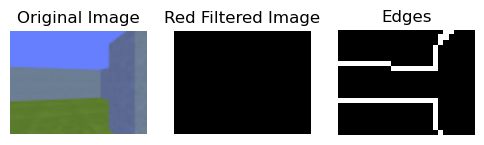

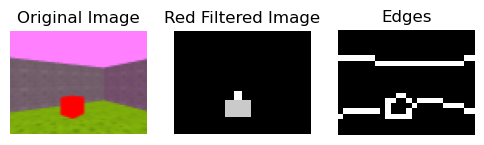

Original feature size: 4800
Size of filtered image: 192
Size of edges image: 520


In [112]:
def filter_red(image, downsample_N=2):
    # Downsample the image by 2
    downscale_size = (image.shape[1] // downsample_N, image.shape[0] // downsample_N)
    downsampled_image = cv2.resize(image, downscale_size)
    # Convert BGR to HSV
    hsv = cv2.cvtColor(downsampled_image, cv2.COLOR_RGB2HSV)
    
    # Define range for red color in HSV
    # Red wraps around in HSV, so we need two ranges
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    
    # Create masks for both ranges
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    
    # Combine the masks
    mask = mask1 + mask2
    
    # Apply the mask to the original image
    output = cv2.bitwise_and(downsampled_image, downsampled_image, mask=mask)
    
    # Convert to gray scale
    output = cv2.cvtColor(output, cv2.COLOR_RGB2GRAY)
    return output

# Set seed
# np.random.seed(42)
# Select one random image for each time id
for id in range(3):
    time_idxs = np.where(time_ids == id)[0]
    random_idx = np.random.choice(time_idxs, 1, replace=False)[0]
    random_image = observations[random_idx]
    filtered_image = filter_red(random_image, downsample_N=5)
    __, edges = downscale_and_detect_edges(random_image, downscale_factor=3)
    
    # Plot the images
    fig, axes = plt.subplots(1, 3, figsize=(6, 3))
    axes[0].imshow(random_image)
    axes[0].axis('off')
    axes[0].set_title('Original Image')
    axes[1].imshow(filtered_image, cmap='gray')
    axes[1].axis('off')
    axes[1].set_title('Red Filtered Image')
    axes[2].imshow(edges, cmap='gray')
    axes[2].axis('off')
    axes[2].set_title('Edges')
    plt.show()

print("Original feature size:" , random_image.shape[0] * random_image.shape[1])
print("Size of filtered image:", filtered_image.shape[0] * filtered_image.shape[1])
print("Size of edges image:", edges.shape[0] * edges.shape[1])



In [139]:
X = []
y = []
for i in range(len(demonstrations)):
    for j in range(len(demonstrations[i]['observations'])):
        X.append(demonstrations[i]['observations'][j])
        y.append(demonstrations[i]['actions'][j])
X = np.array(X)
y = np.array(y)

# Balance X and y for all classes
X_balanced = []
y_balanced = []

for c in np.unique(y):
    X_c = X[y == c]
    y_c = y[y == c]
    X_resampled, y_resampled = resample(X_c, y_c, replace=True, n_samples=500, random_state=42)
    X_balanced.extend(X_resampled)
    y_balanced.extend(y_resampled)

X_balanced = np.array(X_balanced)
y_balanced = np.array(y_balanced)

print('Original dataset:', Counter(y))
print('Balanced dataset:', Counter(y_balanced))

print(X_balanced.shape)
print(y_balanced.shape)

Original dataset: Counter({2: 3088, 0: 509, 1: 352})
Balanced dataset: Counter({0: 500, 1: 500, 2: 500})
(1500, 60, 80, 3)
(1500,)


In [140]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Function to evaluate a feature extractor
def evaluate_feature_extractor(feature_extractor, param_values):
    best_score = 0
    best_params = None

    for params in param_values:
        # Extract features from training data
        X_train_features = np.array([feature_extractor(image, **params) for image in X_train])

        if X_train_features.ndim == 1:
            X_train_features = np.asarray([X_train_features]).reshape(-1, 1)
            
        # print(X_train_features.shape)
        # Train the classifier
        clf = RandomForestClassifier()
        clf.fit(X_train_features, y_train)
        
        # Extract features from test data
        X_test_features = np.array([feature_extractor(image, **params) for image in X_test])
        if X_test_features.ndim == 1:
            X_test_features = np.asarray([X_test_features]).reshape(-1, 1)
        # Predict and evaluate
        y_pred = clf.predict(X_test_features)
        score = accuracy_score(y_test, y_pred)
        
        # Track the best parameters and score
        if score > best_score:
            best_score = score
            best_params = params
        return best_params
    print(f"Best Parameters for {feature_extractor.__name__}: {best_params}")
    print(f"Best Score: {best_score}")
    
# Example parameter values for each feature extractor
color_means_params = [{'N_mean': 4, 'M_mean': 4}, {'N_mean': 8, 'M_mean': 8}, {'N_mean': 4, 'M_mean': 8}, {'N_mean': 8, 'M_mean': 4}]
color_stds_params = [{'N_std': 4, 'M_std': 4}, {'N_std': 8, 'M_std': 8}, {'N_std': 4, 'M_std': 8}, {'N_std': 8, 'M_std': 4}]
edge_detection_params = [{'low_e': 10*i, 'high_e': 10*i + 10*j} for i in range(15) for j in range(1, 10)]
hog_features_params = [{'win_size': (64, 64), 'block_size': (16, 16), 'block_stride': (8, 8), 'cell_size': (8, 8), 'nbins': 9}, 
                       {'win_size': (128, 128), 'block_size': (32, 32), 'block_stride': (16, 16), 'cell_size': (16, 16), 'nbins': 18}]
texture_analysis_params = [{'radius': 1, 'n_points': 8}, {'radius': 2, 'n_points': 16}]
line_detection_params = [{'low_l': 50, 'high_l': 150, 'rho': 1, 'theta': np.pi/180, 'threshold': 100},
                         {'low_l': 100, 'high_l': 200, 'rho': 1, 'theta': np.pi/180, 'threshold': 150},
                         {'low_l': 50, 'high_l': 150, 'rho': 1, 'theta': np.pi/180, 'threshold': 150},
                         {'low_l': 100, 'high_l': 200, 'rho': 1, 'theta': np.pi/180, 'threshold': 100},
                         {'low_l': 50, 'high_l': 150, 'rho': 1, 'theta': np.pi/180, 'threshold': 200},
                         {'low_l': 100, 'high_l': 200, 'rho': 1, 'theta': np.pi/180, 'threshold': 200}, 
                         {'low_l': 50, 'high_l': 150, 'rho': 1, 'theta': np.pi/180, 'threshold': 50},
                         {'low_l': 100, 'high_l': 200, 'rho': 1, 'theta': np.pi/180, 'threshold': 50}]


# Evaluate each feature extractor separately
color_means_params = evaluate_feature_extractor(color_means, color_means_params)
color_stds_params = evaluate_feature_extractor(color_stds, color_stds_params)
edge_detect_params = evaluate_feature_extractor(edge_detection, edge_detection_params)
texture_analysis_params = evaluate_feature_extractor(texture_analysis, texture_analysis_params)
line_detection_params = evaluate_feature_extractor(line_detection, line_detection_params)


In [146]:
print(f"Best Parameters for color_means: {color_means_params}")
print(f"Best Parameters for color_stds: {color_stds_params}")
print(f"Best Parameters for edge_detection: {edge_detect_params}")
print(f"Best Parameters for texture_analysis: {texture_analysis_params}")
print(f"Best Parameters for line_detection: {line_detection_params}")


Best Parameters for color_means: {'N_mean': 4, 'M_mean': 4}
Best Parameters for color_stds: {'N_std': 4, 'M_std': 4}
Best Parameters for edge_detection: {'low_e': 0, 'high_e': 10}
Best Parameters for texture_analysis: {'radius': 1, 'n_points': 8}
Best Parameters for line_detection: {'low_l': 50, 'high_l': 150, 'rho': 1, 'theta': 0.017453292519943295, 'threshold': 100}


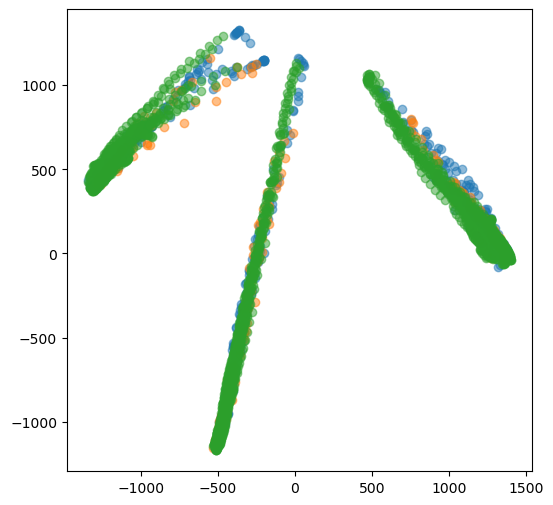

In [147]:
# Extract features from all images
params = color_means_params | color_stds_params | edge_detect_params | texture_analysis_params | line_detection_params
X_features = np.array([extract_features(image, params) for image in X])

# Perform PCA to reduce the dimensionality
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_features)

# Select the first two principal components
X_2d = X_pca[:, :2]

# Plot the clusters
plt.figure(figsize=(6, 6))
for c in np.unique(y):
    plt.scatter(X_2d[y == c, 0], X_2d[y == c, 1], alpha=0.5, label=f'Class {c}')



N, M: 4, 4
[139.1875 133.      85.1875]
[185.9375 175.3125 109.5   ]
[151.875  144.5     91.5625]
[144.625  138.      88.0625]
[148.8125 142.      90.5   ]
[151.1875 145.375   92.875 ]
[155.4375 150.      95.875 ]
[230.5625 183.4375 102.75  ]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[252.9375 189.5    101.25  ]
[145.875  110.3125  64.8125]
[122.5    94.75   57.875]
[118.3125  93.9375  57.75  ]
[162.3125 153.8125  97.1875]
[184.375  173.625  108.4375]
[141.9375 135.4375  86.5   ]
[143.75   137.6875  87.9375]
[151.125  144.1875  91.75  ]
[151.25   144.9375  92.125 ]
[153.4375 147.875   94.6875]
[230.3125 183.4375 102.75  ]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[255. 191. 102.]
[201.125  151.25    83.4375]
[125.9375  96.      57.75  ]
[123.875   96.0625  58.6875]
[119.8125  94.1875  57.4375]
[158.     148.1875  93.3

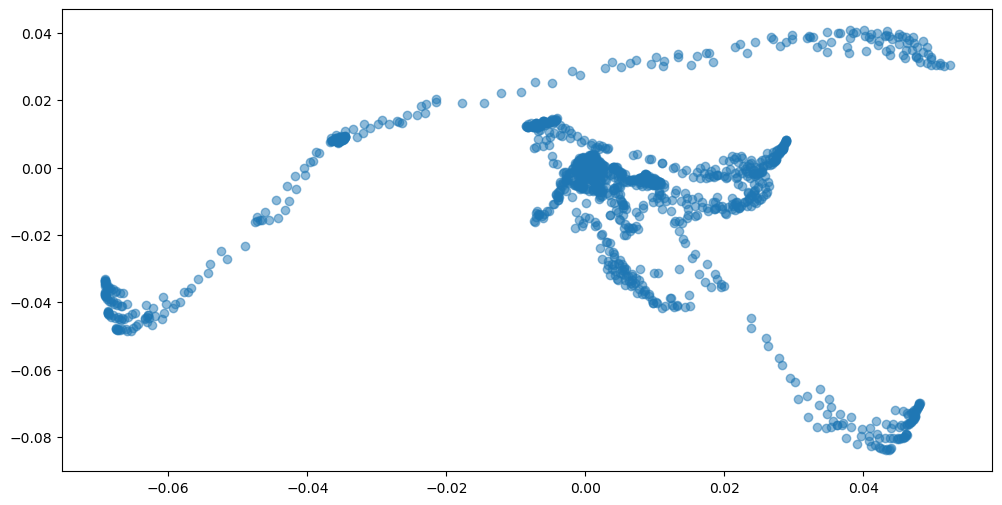

In [156]:
# Find the most relevant features
feature_funcs = [color_means, color_stds, edge_detection, texture_analysis, line_detection]

n_outputs = []
test_img = X[0]
# Find number of outputs per feature
n_outputs_means = len(color_means(test_img, **color_means_params))
n_outputs_stds = len(color_stds(test_img, **color_stds_params))
n_outputs_edge = 1
n_outputs_texture = len(texture_analysis(test_img, **texture_analysis_params))
n_outputs_line = 1

n_outputs.extend([n_outputs_means, n_outputs_stds, n_outputs_edge, n_outputs_texture, n_outputs_line])
print(n_outputs)
loadings = pca.components_.T

# Plot the loadings of the first two principal components
plt.figure(figsize=(12, 6))
plt.scatter(loadings[:, 0], loadings[:, 1], alpha=0.5)



In [51]:
import numpy as np
import random
from collections import deque
import tensorflow as tf
from tensorflow.keras import layers, models
import gym

# Define the DQN agent
class DQNAgent:
    def __init__(self, state_shape, num_actions, batch_size=32):
        self.state_shape = state_shape
        self.num_actions = num_actions
        self.batch_size = batch_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95  # Discount factor
        self.epsilon = 1.0  # Exploration rate
        self.epsilon_min = 0.1
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (8, 8), strides=4, activation='relu', input_shape=self.state_shape))
        model.add(layers.Conv2D(64, (4, 4), strides=2, activation='relu'))
        model.add(layers.Conv2D(64, (3, 3), strides=1, activation='relu'))
        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='relu'))
        model.add(layers.Dense(self.num_actions, activation='linear'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate),
                      loss='mse')
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.num_actions)
        # Convert state to tensor
        state_tensor = tf.convert_to_tensor(state, dtype=tf.float32)
        q_values = self.model(state_tensor, training=False)  # Use model in inference mode
        return np.argmax(q_values.numpy()[0])  # Convert back to numpy for argmax

    def replay(self, batch_size):
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            # Convert states to tensors
            state_tensor = tf.convert_to_tensor(state, dtype=tf.float32)
            next_state_tensor = tf.convert_to_tensor(next_state, dtype=tf.float32)

            target = reward
            if not done:
                target += self.gamma * np.amax(self.model(next_state_tensor, training=False).numpy()[0])
            target_f = self.model(state_tensor, training=False).numpy()  # Get predictions as numpy
            target_f[0][action] = target
            # Train the model with the updated target
            self.model.fit(state_tensor, target_f, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def train_with_simulation(env, agent, episodes, max_steps=500):
    for episode in range(episodes):
        # Define policy function that uses the agent
        def agent_policy(obs):
            obs = np.reshape(obs, [1, *agent.state_shape])
            return agent.act(obs)

        # Run simulation and collect data
        rewards, observations, actions, _ = run_simulation(
            agent_policy,
            env,
            max_steps=max_steps,
            verbose=0,
            record_data=True,
            delay=0.0,
            seed=episode
        )

        print(f"Episode {episode + 1}: Total Reward = {np.sum(rewards)}")

        # Learn from the collected data
        for i in range(len(observations) - 1):
            state = np.reshape(observations[i], [1, *agent.state_shape])
            action = actions[i]
            reward = rewards[i]
            next_state = np.reshape(observations[i + 1], [1, *agent.state_shape])
            done = i == len(observations) - 2
            agent.remember(state, action, reward, next_state, done)

        if len(agent.memory) > agent.batch_size:
            agent.replay(agent.batch_size)

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

In [54]:
# Initialize environment and agent
env = envs[0]
state_shape = (60, 80, 3)  # Example shape, adjust to your environment
num_actions = 3  # Number of actions

agent = DQNAgent(state_shape, num_actions)

# Train the agent using the simulation
train_with_simulation(env, agent, episodes=1000)

Episode 1: Total Reward = 0
Episode 2: Total Reward = 0
Episode 3: Total Reward = 0
Episode 4: Total Reward = 0
Episode 5: Total Reward = 0
Episode 6: Total Reward = 0
Episode 7: Total Reward = 0
Episode 8: Total Reward = 0
Episode 9: Total Reward = 0
Episode 10: Total Reward = 0.9612
Episode 11: Total Reward = 0
Episode 12: Total Reward = 0
Episode 13: Total Reward = 0
Episode 14: Total Reward = 0.9632000000000001
Episode 15: Total Reward = 0
Episode 16: Total Reward = 0
Episode 17: Total Reward = 0
Episode 18: Total Reward = 0
Episode 19: Total Reward = 0
Episode 20: Total Reward = 0
Episode 21: Total Reward = 0
Episode 22: Total Reward = 0
Episode 23: Total Reward = 0
Episode 24: Total Reward = 0
Episode 25: Total Reward = 0
Episode 26: Total Reward = 0
Episode 27: Total Reward = 0
Episode 28: Total Reward = 0
Episode 29: Total Reward = 0
Episode 30: Total Reward = 0
Episode 31: Total Reward = 0
Episode 32: Total Reward = 0
Episode 33: Total Reward = 0
Episode 34: Total Reward = 0
E

KeyboardInterrupt: 

In [36]:
# Run Bayesian optimization
result = gp_minimize(
    func=objective,
    dimensions=param_space,
    n_calls=20,        # Number of evaluations
    n_random_starts=5, # Number of random initialization points
    random_state=42
)

NameError: name 'state_shape' is not defined

NameError: name 'env' is not defined

----

# 3. Single Time of Day Action Classification  (35 points)
To get started, we will train and test a model that is only suitable for operating at a single time of day, i.e., at Time 1

As a first step split the data into a training, validation, and test set. You can use the originally provided data, or collect your own.

<div class="alert alert-block alert-warning">
Remember to provide thorough insights, analysis and reasoning behind your design choices and what you see as a consequence of these choices. Try to synthesize rather than describing what you did step by step.
</div>


## 3.1. Shortlist Promising Models (25 points)
1. Compare at least 2 models. One of them needs to be a neural network, one of them needs to be not a neural network.<span style="float: right;">(3 pt)</span>
2. For each of the models that you are going to compare, explain what are its relative advantages/disadvantages in terms of training<br> time, test time, and number of model parameters compared to the other choices. Also explain how these considerations relate to<br> the target application, and motivate which type of model would be preferred based on these considerations only (so disregarding<br> the actual quality of the models). <span style="float: right;">(10 pt)</span>
3. If needed, perform dimensionality reduction before training your selection models. Explain why it is (not) needed.<span style="float: right;">(1.5 pt)</span>
4. Roughly tune those models<span style="float: right;">(1 pt)</span>
5. Evaluate the models in terms of performance, bias, variance, etc.<span style="float: right;">(5 pt)</span>
6. Please use the macro-F1 score (see sklearn documentation) as your main criterion. Looking at confusion matrices, accuracy etc.<br> might also provide valuable insights. Why is the accuracy score potentially problematic in this setting?<span style="float: right;">(1.5 pt)</span>
7. Pick one algorithm to develop further. Motivate your choice of algorithm with your results.<span style="float: right;">(3 pt)</span>


In [ ]:
# Add code and markdown cells

## 3.2. Fine-Tune the System (10 points)
1. What are the most important hyperparameters of your chosen algorithm?<span style="float: right;">(2 pt)</span>
2. Perform hyperparameter optimization (including pre-processing steps)<span style="float: right;">(2 pt)</span>
3. Compare at least 3 models with different sets of hyperparameters <span style="float: right;">(1 pt)</span>
4. Evaluate the final model (similar to "Shortlist Promising Models" above)<span style="float: right;">(5 pt)</span>

In [ ]:
# Add code and markdown cells

---

# 4. Enabling Generalization (20 points)
Now we are going to train and test a single model that is suitable for operating at all times of the day, i.e., a model that can generalize between times of day and even to unseen times of day, and that is robust to different lighting conditions. The idea is to take the final model you developed above as a starting point and to develop it further for generalization.

The simulator provides you access to Time 3. However, this is to be treated as the test set, i.e., you are only allowed to test your model on it as the very final step. I.e., do not tweak your model after running that environment, you would be overfitting to the test data. Performance on the Time 3 environment will NOT influence your grade.


1. How can the 3 provided datasets be used to train a model that can generalize, and even more importantly how can they be used to<br> evaluate whether a model can generalize? (Hint: Lecture 2)<span style="float: right;">(2 pt)</span>
2. Above you designed features for action classification. Evaluate whether those features are suitable for generalization. If necessary<br> adapt the feature extraction. <span style="float: right;">(2 pt)</span>
3. Compare how well models trained just on the data from Time 1 and models trained on data from multiple times of day generalize to<br> unseen times of day (using the approach from the first bullet, do *not* use Time 3 for this comparison). Make sure that this is a fair<br> comparison, e.g., in terms of the amount and quality of the data.<span style="float: right;">(3 pt)</span>
4. Discuss at least 2 methods that can be employed to make your model perform better and be robust to the variations we have in this<br> scenario (methods for any step are fine: data collection, data augmentation, pre-processing, model structure, training, etc.)<span style="float: right;">(3 pt)</span>
5. Implement at least one of those methods.<span style="float: right;">(1 pt)</span>
6. Evaluate the final model (similar to "Shortlist Promising Models" above) for generalization making use only of data from Time 0,<br> Time 1, and Time 2.<span style="float: right;">(5 pt)</span>
7. Test the final model on the Time 3 environment and discuss its performance.<span style="float: right;">(3 pt)</span>
8. Save the parameters of your best multi scenario model to your hard drive (use pickle for sklearn or built-in save/load for keras), you<br> will need to be able to reload your model without training in the next step. Be sure to include the saved parameters in your zip file so<br> we can evaluate your best model too, even without rerunning the notebook up to here.<span style="float: right;">(1 pt)</span>

<div class="alert alert-block alert-warning">
Remember to provide thorough insights, analysis and reasoning behind your design choices and what you see as a consequence of these choices. Try to synthesize rather than describing what you did step by step.
</div>

In [ ]:
# Add code and markdown cells

---

# 5. Present Your Solution (5 points)
1. Summarize your main decisions and insights <span style="float: right;">(2.5 pt)</span>
2. Create a stand-alone demo. I.e., a block of cells that can be run on its own. For that you will need to load your pre-trained best<br> model you saved in the previous section and run it on Time 3.<span style="float: right;">(2.5 pt)</span>


In [ ]:
# Add code and markdown cells